# Credit Risk IFRS9 Framework  
## Notebook 2 – Data Cleaning and Target Definition

### Objective of this notebook

The purpose of this notebook is to transform the raw Lending Club loan dataset into a clean modelling dataset that can be used for credit risk modelling.

The dataset used in this project contains historical information about loans issued by Lending Club between 2007 and 2018, including borrower characteristics, loan attributes and loan outcomes.

While the raw dataset contains more than 150 variables, many of them are not suitable for predictive modelling. Some variables contain extremely high levels of missing values, while others correspond to information that becomes available after the loan has been issued, which would introduce data leakage if used in a default prediction model.

The goal of this notebook is therefore to construct a consistent and reproducible modelling dataset that preserves only the information that would realistically be available at the moment of loan origination.

### Key tasks performed in this notebook

This notebook performs the following steps:

1. Load the Lending Club dataset from the raw data folder.
2. Analyse the level of missing values across variables.
3. Remove variables with extremely high levels of missing data.
4. Remove variables that are not suitable for modelling, including:
   - administrative identifiers
   - secondary applicant variables
   - hardship program variables
   - settlement variables
   - variables containing post-default or recovery information
5. Construct the binary target variable `default_flag` using the `loan_status` field.
6. Validate the resulting dataset structure and target distribution.
7. Export the cleaned dataset for use in the next stage of the modelling pipeline.

### Definition of the modelling target

The target variable in this project is a binary indicator of credit default, defined using the `loan_status` variable:

- `default_flag = 1` for loans with status  
  Charged Off, Default, or Late (31–120 days)

- `default_flag = 0` for loans with status  
  Fully Paid

Loans with status Current are excluded from the modelling dataset because their final outcome is not yet known.

This definition provides a simplified but practical proxy for borrower default behaviour, suitable for the purposes of building a credit risk modelling pipeline.

### Output of this notebook

The final output of this notebook is a cleaned dataset containing:

- the selected explanatory variables
- the binary target variable `default_flag`

This dataset will be saved as:

data/processed/lending_club_clean.parquet

It will serve as the input dataset for the next notebook, where feature engineering and portfolio segmentation will be performed as part of the credit risk modelling framework.

## 1. Environment setup

This section defines the working environment for the notebook.

The main objective is to ensure that the analysis is reproducible and portable across different machines. For that reason, all file paths are built relative to the project root using `pathlib`, avoiding hardcoded system-specific locations.

In this section, we import the required libraries, configure display options and define the main project paths that will be used throughout the notebook.

In [2]:
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 140)
pd.set_option("display.max_colwidth", 120)

In [4]:
from pathlib import Path

# Project root (one level above notebooks/)
project_root = Path.cwd().parent

data_raw_dir = project_root / "data" / "raw"
data_processed_dir = project_root / "data" / "processed"

input_file = data_raw_dir / "accepted_2007_to_2018Q4.csv.gz"
output_file = data_processed_dir / "lending_club_clean.parquet"

print("Project root:", project_root)
print("Input file:", input_file)

Project root: /home/apalo/Credit-Risk-Ifrs9
Input file: /home/apalo/Credit-Risk-Ifrs9/data/raw/accepted_2007_to_2018Q4.csv.gz


## 2. Data loading

In this section we load the Lending Club dataset from the raw data folder.

The dataset contains historical information about loans issued between 2007 and 2018 and includes borrower characteristics, loan attributes and loan outcomes. Because the dataset contains a large number of variables, the first step is to load the file and inspect its basic structure.

The objective of this step is to confirm that the dataset has been loaded correctly and to obtain a first overview of its dimensions, columns and data types before performing any cleaning operations.

In [5]:
sample_rows = 1_000_000

df = pd.read_csv(
    input_file,
    compression="gzip",
    low_memory=True,
    nrows=sample_rows
)

print("Dataset sample loaded successfully")
print("Shape:", df.shape)

Dataset sample loaded successfully
Shape: (1000000, 151)


In [6]:
df.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,fico_range_low,fico_range_high,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,last_fico_range_high,last_fico_range_low,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_act_il,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_bc_dlq,mths_since_recent_inq,mths_since_recent_revol_delinq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,revol_bal_joint,sec_app_fico_range_low,sec_app_fico_range_high,sec_app_earliest_cr_line,sec_app_inq_last_6mths,sec_app_mort_acc,sec_app_open_acc,sec_app_revol_util,sec_app_open_act_il,sec_app_num_rev_accts,sec_app_chargeoff_within_12_mths,sec_app_collections_12_mths_ex_med,sec_app_mths_since_last_major_derog,hardship_flag,hardship_type,hardship_reason,hardship_status,deferral_term,hardship_amount,hardship_start_date,hardship_end_date,payment_plan_start_date,hardship_length,hardship_dpd,hardship_loan_status,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,leadman,10+ years,MORTGAGE,55000.0,Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.action?loan_id=68407277,NaN,debt_consolidation,Debt consolidation,190xx,PA,5.91,0.0,Aug-2003,675.0,679.0,1.0,30.0,NaN,7.0,0.0,2765.0,29.7,13.0,w,0.00,0.00,4421.723917,4421.72,3600.00,821.72,0.0,0.0,0.0,Jan-2019,122.67,NaN,Mar-2019,564.0,560.0,0.0,30.0,1.0,Individual,NaN,NaN,NaN,0.0,722.0,144904.0,2.0,2.0,0.0,1.0,21.0,4981.0,36.0,3.0,3.0,722.0,34.0,9300.0,3.0,1.0,4.0,4.0,20701.0,1506.0,37.2,0.0,0.0,148.0,128.0,3.0,3.0,1.0,4.0,69.0,4.0,69.0,2.0,2.0,4.0,2.0,5.0,3.0,4.0,9.0,4.0,7.0,0.0,0.0,0.0,3.0,76.9,0.0,0.0,0.0,178050.0,7746.0,2400.0,13734.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,Engineer,10+ years,MORTGAGE,65000.0,Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.action?loan_id=68355089,NaN,small_business,Business,577xx,SD,16.06,1.0,Dec-1999,715.0,719.0,4.0,6.0,NaN,22.0,0.0,21470.0,19.2,38.0,w,0.00,0.00,25679.660000,25679.66,24700.00,979.66,0.0,0.0,0.0,Jun-2016,926.35,NaN,Mar-2019,699.0,695.0,0.0,NaN,1.0,Individual,NaN,NaN,NaN,0.0,0.0,204396.0,1.0,1.0,0.0,1.0,19.0,18005.0,73.0,2.0,3.0,6472.0,29.0,111800.0,0.0,0.0,6.0,4.0,9733.0,57830.0,27.1,0.0,0.0,113.0,192.0,2.0,2.0,4.0,2.0,NaN,0.0,6.0,0.0,5.0,5.0,13.0,17.0,6.0,20.0,27.0,5.0,22.0,0.0,0.0,0.0,2.0,97.4,7.7,0.0,0.0,314017.0,39475.0,79300

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Columns: 151 entries, id to settlement_term
dtypes: float64(113), object(1), str(37)
memory usage: 1.3+ GB


In [8]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 1000000
Number of columns: 151


In [9]:
print("First 20 column names:")
print(df.columns[:20].tolist())

First 20 column names:
['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_title', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'loan_status', 'pymnt_plan', 'url', 'desc']


## 3. Missing value analysis

The raw Lending Club dataset contains many variables with very limited coverage. Several columns are nearly empty because they relate to exceptional workflows, secondary applicants, hardship arrangements or post-default processes.

To simplify the modelling pipeline and improve data quality, we analyse missing values across all variables and remove columns with extremely high levels of missing data.

In this notebook, the operational threshold is set at 90 percent missing values. This rule does not replace business judgement, but it provides a practical first filter to remove columns with insufficient information.

In [10]:
missing_pct = df.isna().mean().sort_values(ascending=False) * 100

missing_summary = (
    missing_pct
    .rename("missing_pct")
    .reset_index()
    .rename(columns={"index": "variable"})
)

missing_summary.head(20)

,variable,missing_pct
0,member_id,100.0000
1,desc,99.9948
2,orig_projected_additional_accrued_interest,99.5468
3,hardship_payoff_balance_amount,99.4337
4,hardship_last_payment_amount,99.4337
5,payment_plan_start_date,99.4337
6,hardship_type,99.4337
7,hardship_status,99.4337
8,hardship_start_date,99.4337
9,deferral_term,99.4337


In [11]:
missing_summary["missing_bucket"] = pd.cut(
    missing_summary["missing_pct"],
    bins=[-0.01, 0, 25, 50, 75, 90, 100],
    labels=["0%", "0-25%", "25-50%", "50-75%", "75-90%", "90-100%"]
)

missing_summary["missing_bucket"].value_counts().sort_index()

missing_bucket
0%          1
0-25%      92
25-50%     14
50-75%      4
75-90%      2
90-100%    38
Name: count, dtype: int64

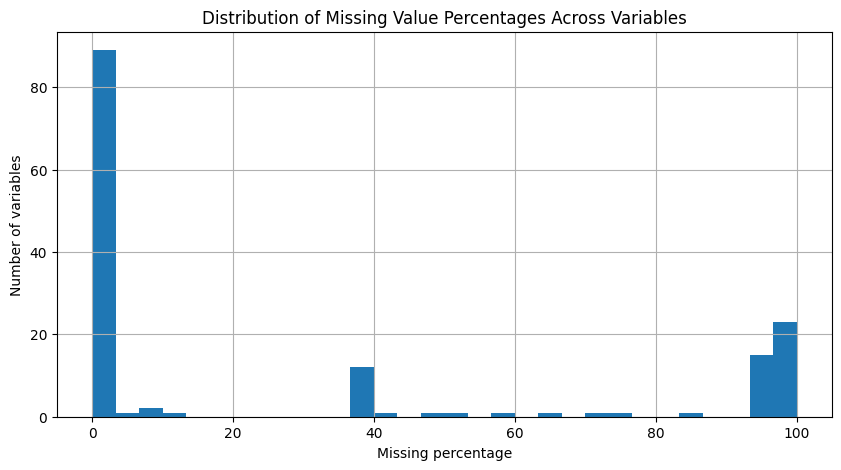

In [12]:
plt.figure(figsize=(10, 5))
missing_summary["missing_pct"].hist(bins=30)
plt.title("Distribution of Missing Value Percentages Across Variables")
plt.xlabel("Missing percentage")
plt.ylabel("Number of variables")
plt.show()

In [13]:
high_missing_cols = missing_pct[missing_pct > 90].index.tolist()

print("Variables with more than 90% missing values:", len(high_missing_cols))
high_missing_cols[:50]

Variables with more than 90% missing values: 38


['member_id',
 'desc',
 'orig_projected_additional_accrued_interest',
 'hardship_payoff_balance_amount',
 'hardship_last_payment_amount',
 'payment_plan_start_date',
 'hardship_type',
 'hardship_status',
 'hardship_start_date',
 'deferral_term',
 'hardship_amount',
 'hardship_dpd',
 'hardship_loan_status',
 'hardship_length',
 'hardship_end_date',
 'hardship_reason',
 'debt_settlement_flag_date',
 'settlement_status',
 'settlement_percentage',
 'settlement_date',
 'settlement_amount',
 'settlement_term',
 'sec_app_mths_since_last_major_derog',
 'sec_app_revol_util',
 'verification_status_joint',
 'sec_app_open_act_il',
 'sec_app_open_acc',
 'revol_bal_joint',
 'sec_app_num_rev_accts',
 'sec_app_mort_acc',
 'sec_app_inq_last_6mths',
 'sec_app_fico_range_high',
 'sec_app_earliest_cr_line',
 'sec_app_chargeoff_within_12_mths',
 'sec_app_collections_12_mths_ex_med',
 'sec_app_fico_range_low',
 'dti_joint',
 'annual_inc_joint']

## 4. Variable filtering

This section removes variables that are not appropriate for a probability of default modelling dataset.

The guiding principle is temporal consistency. Only variables that would reasonably be available at the moment of loan origination should remain in the modelling base.

The following categories of variables are removed:

1. Variables with more than 90 percent missing values
2. Identifier columns
3. Secondary applicant variables
4. Hardship-related variables
5. Settlement-related variables
6. Post-default, recovery and collection variables
7. Additional administrative or clearly leakage-prone variables

This filtering step is essential to avoid data leakage and to produce a clean dataset suitable for subsequent feature engineering and modelling.

In [14]:
initial_columns = df.columns.tolist()

In [15]:
# 4.1 Identifier columns
identifier_cols = [
    "id",
    "member_id"
]

identifier_cols = [col for col in identifier_cols if col in df.columns]
identifier_cols

['id', 'member_id']

In [16]:
# 4.2 Pattern-based variable families
secondary_app_cols = [col for col in df.columns if col.startswith("sec_app")]
hardship_cols = [col for col in df.columns if col.startswith("hardship")]
settlement_cols = [col for col in df.columns if col.startswith("settlement")]

In [17]:
print("Secondary applicant columns:", len(secondary_app_cols))
print("Hardship columns:", len(hardship_cols))
print("Settlement columns:", len(settlement_cols))

Secondary applicant columns: 12
Hardship columns: 12
Settlement columns: 5


In [18]:
# 4.3 Explicit post-origination or leakage-prone variables

post_origination_cols = [
    "out_prncp",
    "out_prncp_inv",
    "total_pymnt",
    "total_pymnt_inv",
    "total_rec_prncp",
    "total_rec_int",
    "total_rec_late_fee",
    "recoveries",
    "collection_recovery_fee",
    "last_pymnt_d",
    "last_pymnt_amnt",
    "next_pymnt_d",
    "last_credit_pull_d"
]

post_origination_cols = [col for col in post_origination_cols if col in df.columns]

print("Post-origination columns:", len(post_origination_cols))
post_origination_cols

Post-origination columns: 13


['out_prncp',
 'out_prncp_inv',
 'total_pymnt',
 'total_pymnt_inv',
 'total_rec_prncp',
 'total_rec_int',
 'total_rec_late_fee',
 'recoveries',
 'collection_recovery_fee',
 'last_pymnt_d',
 'last_pymnt_amnt',
 'next_pymnt_d',
 'last_credit_pull_d']

In [19]:
# 4.4 Combine all removal candidates

cols_to_remove = set()

cols_to_remove.update(high_missing_cols)
cols_to_remove.update(identifier_cols)
cols_to_remove.update(secondary_app_cols)
cols_to_remove.update(hardship_cols)
cols_to_remove.update(settlement_cols)
cols_to_remove.update(post_origination_cols)

# Keep loan_status because it is needed to build the target
cols_to_remove.discard("loan_status")

cols_to_remove = sorted(list(cols_to_remove))

print("Total columns marked for removal:", len(cols_to_remove))

Total columns marked for removal: 53


In [20]:
# Drop selected columns

df_clean = df.drop(columns=cols_to_remove, errors="ignore").copy()

print("Original shape:", df.shape)
print("Shape after variable filtering:", df_clean.shape)

Original shape: (1000000, 151)
Shape after variable filtering: (1000000, 98)


In [21]:
removed_columns = sorted(list(set(df.columns) - set(df_clean.columns)))
print("Number of removed columns:", len(removed_columns))

Number of removed columns: 53


## 5. Target variable construction

The modelling target is constructed from the `loan_status` variable.

Only observations with a clearly interpretable outcome are retained. Loans with status Fully Paid are treated as non-default observations, while loans with status Charged Off, Default and Late (31-120 days) are treated as default observations.

Loans in Current status are excluded because their final repayment outcome is not yet observed. Other intermediate statuses are also excluded to keep the target definition clear and consistent.

In [22]:
df_clean["loan_status"].value_counts(dropna=False)

loan_status
Fully Paid            450285
Current               411982
Charged Off           121189
Late (31-120 days)     10475
In Grace Period         3997
Late (16-30 days)       2040
Default                   20
NaN                       12
Name: count, dtype: int64

In [23]:
target_status_mapping = {
    "Fully Paid": 0,
    "Charged Off": 1,
    "Default": 1,
    "Late (31-120 days)": 1
}

valid_statuses = list(target_status_mapping.keys())

df_model = df_clean[df_clean["loan_status"].isin(valid_statuses)].copy()

print("Shape after keeping valid loan_status values:", df_model.shape)
print(df_model["loan_status"].value_counts())

Shape after keeping valid loan_status values: (581969, 98)
loan_status
Fully Paid            450285
Charged Off           121189
Late (31-120 days)     10475
Default                   20
Name: count, dtype: int64


In [24]:
df_model["default_flag"] = df_model["loan_status"].map(target_status_mapping)

df_model["default_flag"].value_counts(dropna=False)

default_flag
0    450285
1    131684
Name: count, dtype: int64

In [25]:
df_model["default_flag"].value_counts(normalize=True).sort_index()

default_flag
0    0.773727
1    0.226273
Name: proportion, dtype: float64

In [26]:
df_model = df_model.drop(columns=["loan_status"])

## 6. Dataset validation

In [27]:
print("Final modelling dataset shape:", df_model.shape)
print("Final number of variables:", df_model.shape[1])

Final modelling dataset shape: (581969, 98)
Final number of variables: 98


In [28]:
target_distribution_abs = df_model["default_flag"].value_counts().sort_index()
target_distribution_pct = df_model["default_flag"].value_counts(normalize=True).sort_index() * 100

print("Default flag distribution (absolute):")
print(target_distribution_abs)

print("\nDefault flag distribution (%):")
print(target_distribution_pct.round(2))

Default flag distribution (absolute):
default_flag
0    450285
1    131684
Name: count, dtype: int64

Default flag distribution (%):
default_flag
0    77.37
1    22.63
Name: proportion, dtype: float64


## 6.2 Check results

In [29]:
duplicate_rows = df_model.duplicated().sum()
print("Number of duplicated rows:", duplicate_rows)

Number of duplicated rows: 0


In [30]:
remaining_missing = (
    df_model.isna().mean()
    .sort_values(ascending=False) * 100
)

remaining_missing.head(20)

mths_since_last_record            81.541457
mths_since_recent_bc_dlq          74.787832
mths_since_last_major_derog       71.000174
il_util                           66.775378
mths_since_recent_revol_delinq    64.505841
mths_since_rcnt_il                62.543194
all_util                          61.492794
open_il_12m                       61.488842
total_bal_il                      61.488842
max_bal_bc                        61.488842
open_acc_6m                       61.488842
open_act_il                       61.488842
open_rv_24m                       61.488842
open_rv_12m                       61.488842
inq_fi                            61.488842
total_cu_tl                       61.488842
inq_last_12m                      61.488842
open_il_24m                       61.488842
mths_since_last_delinq            48.713591
mths_since_recent_inq              9.787807
dtype: float64

## 7. Dataset export

In this final step, the cleaned modelling dataset is exported to the processed data directory.

The dataset created in this notebook represents the modelling base that will be used in the following stages of the project. It contains the selected explanatory variables together with the binary target variable `default_flag`, constructed from the `loan_status` field.

The dataset is saved in parquet format, which provides several advantages over CSV files, including smaller file size, faster read times and better compatibility with analytical workflows.

This exported dataset will serve as the input for the next notebook, where feature engineering and portfolio segmentation will be performed before building the probability of default models.

In [31]:
df_model.to_parquet(output_file, index=False)

print("Clean dataset saved successfully.")
print("File location:", output_file)

Clean dataset saved successfully.
File location: /home/apalo/Credit-Risk-Ifrs9/data/processed/lending_club_clean.parquet


In [32]:
# Quick validation of the exported file
df_check = pd.read_parquet(output_file)

print("Reloaded dataset shape:", df_check.shape)
df_check.head()

Reloaded dataset shape: (581969, 98)


,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,pymnt_plan,url,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,fico_range_low,fico_range_high,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,last_fico_range_high,last_fico_range_low,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_act_il,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_bc_dlq,mths_since_recent_inq,mths_since_recent_revol_delinq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,disbursement_method,debt_settlement_flag,default_flag
0,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,leadman,10+ years,MORTGAGE,55000.0,Not Verified,Dec-2015,n,https://lendingclub.com/browse/loanDetail.action?loan_id=68407277,debt_consolidation,Debt consolidation,190xx,PA,5.91,0.0,Aug-2003,675.0,679.0,1.0,30.0,NaN,7.0,0.0,2765.0,29.7,13.0,w,564.0,560.0,0.0,30.0,1.0,Individual,0.0,722.0,144904.0,2.0,2.0,0.0,1.0,21.0,4981.0,36.0,3.0,3.0,722.0,34.0,9300.0,3.0,1.0,4.0,4.0,20701.0,1506.0,37.2,0.0,0.0,148.0,128.0,3.0,3.0,1.0,4.0,69.0,4.0,69.0,2.0,2.0,4.0,2.0,5.0,3.0,4.0,9.0,4.0,7.0,0.0,0.0,0.0,3.0,76.9,0.0,0.0,0.0,178050.0,7746.0,2400.0,13734.0,Cash,N,0
1,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,Engineer,10+ years,MORTGAGE,65000.0,Not Verified,Dec-2015,n,https://lendingclub.com/browse/loanDetail.action?loan_id=68355089,small_business,Business,577xx,SD,16.06,1.0,Dec-1999,715.0,719.0,4.0,6.0,NaN,22.0,0.0,21470.0,19.2,38.0,w,699.0,695.0,0.0,NaN,1.0,Individual,0.0,0.0,204396.0,1.0,1.0,0.0,1.0,19.0,18005.0,73.0,2.0,3.0,6472.0,29.0,111800.0,0.0,0.0,6.0,4.0,9733.0,57830.0,27.1,0.0,0.0,113.0,192.0,2.0,2.0,4.0,2.0,NaN,0.0,6.0,0.0,5.0,5.0,13.0,17.0,6.0,20.0,27.0,5.0,22.0,0.0,0.0,0.0,2.0,97.4,7.7,0.0,0.0,314017.0,39475.0,79300.0,24667.0,Cash,N,0
2,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,truck driver,10+ years,MORTGAGE,63000.0,Not Verified,Dec-2015,n,https://lendingclub.com/browse/loanDetail.action?loan_id=68341763,home_improvement,NaN,605xx,IL,10.78,0.0,Aug-2000,695.0,699.0,0.0,NaN,NaN,6.0,0.0,7869.0,56.2,18.0,w,704.0,700.0,0.0,NaN,1.0,Joint App,0.0,0.0,189699.0,0.0,1.0,0.0,4.0,19.0,10827.0,73.0,0.0,2.0,2081.0,65.0,14000.0,2.0,5.0,1.0,6.0,31617.0,2737.0,55.9,0.0,0.0,125.0,184.0,14.0,14.0,5.0,101.0,NaN,10.0,NaN,0.0,2.0,3.0,2.0,4.0,6.0,4.0,7.0,3.0,6.0,0.0,0.0,0.0,0.0,100.0,50.0,0.0,0.0,218418.0,18696.0,6200.0,14877.0,Cash,N,0
3,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,Contract Specialist,3 years,MORTGAGE,104433.0,Source Verified,Dec-2015,n,https://lendingclub.com/browse/loanDetail.action?loan_id=68476807,major_purchase,Major purchase,174xx,PA,25.37,1.0,Jun-1998,695.0,699.0,3.0,12.0,NaN,12.0,0.0,21929.0,64.5,35.0,w,704.0,700.0,0.0,NaN,1.0,Individual,0.0,0.0,331730.0,1.0,3.0,0.0,3.0,14.0,73839.0,84.0,4.0,7.0,9702.0,78.0,34000.0,2.0,1.0,3.0,10.0,27644.0,4567.0,77.5,0.0,0.0,128.0,210.0,4.0,4.0,6.0,4.0,12.0,1.0,12.0,0.0,4.0,6.0,5.0,9.0,10.0,7.0,19.0,6.0,12.0,0.0,0.0,0.0,4.0,96.6,60.0,0.0,0.0,439570.0,95768.0,20300.0,88097.0,Cash,N,0
4,11950.0,11950.0,11950.0,36 months,13.44,405.18,C,C3,Veterinary Tecnician,4 years,RENT,34000.0,Source Verified,Dec-2015,n,https://lending

## Conclusion

In this notebook we transformed the raw Lending Club dataset into a clean and consistent modelling dataset suitable for credit risk analysis.

The main steps performed in this notebook were:

- Loading the Lending Club dataset and inspecting its structure.
- Analysing the distribution of missing values across variables.
- Removing variables with extremely high levels of missing data.
- Filtering out variables related to secondary applicants, hardship programs and debt settlement processes.
- Eliminating post-origination variables that could introduce data leakage in a probability of default model.
- Defining a binary target variable (`default_flag`) based on the `loan_status` field.
- Validating the resulting dataset and exporting it in parquet format.

The final modelling dataset contains:

- **581,969 loans**
- **98 variables**
- **Default rate ≈ 22.6%**

In the next notebook we will perform feature engineering and portfolio segmentation, preparing the variables for probability of default modelling within the simplified IFRS9 credit risk framework.